In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

plt.rcParams['figure.figsize'] = (12, 8)

path = 'recording.wav'
y, sr = librosa.load(path)

Cách thức để tạo ra phổ biên độ tuyến tính và logarit được trình bày dưới đây. 
Chúng ta có thể quan sát thấy rằng cả hai thành phần tần số biên độ nhỏ và lớn đều hiển thị rõ ràng trong phổ biên độ logarit so với phổ biên độ tuyến tính. 
Hình 1 cho thấy dạng sóng tín hiệu tiếng nói, phổ biên độ tuyến tính và phổ biên độ logarit của tín hiệu tiếng nói.

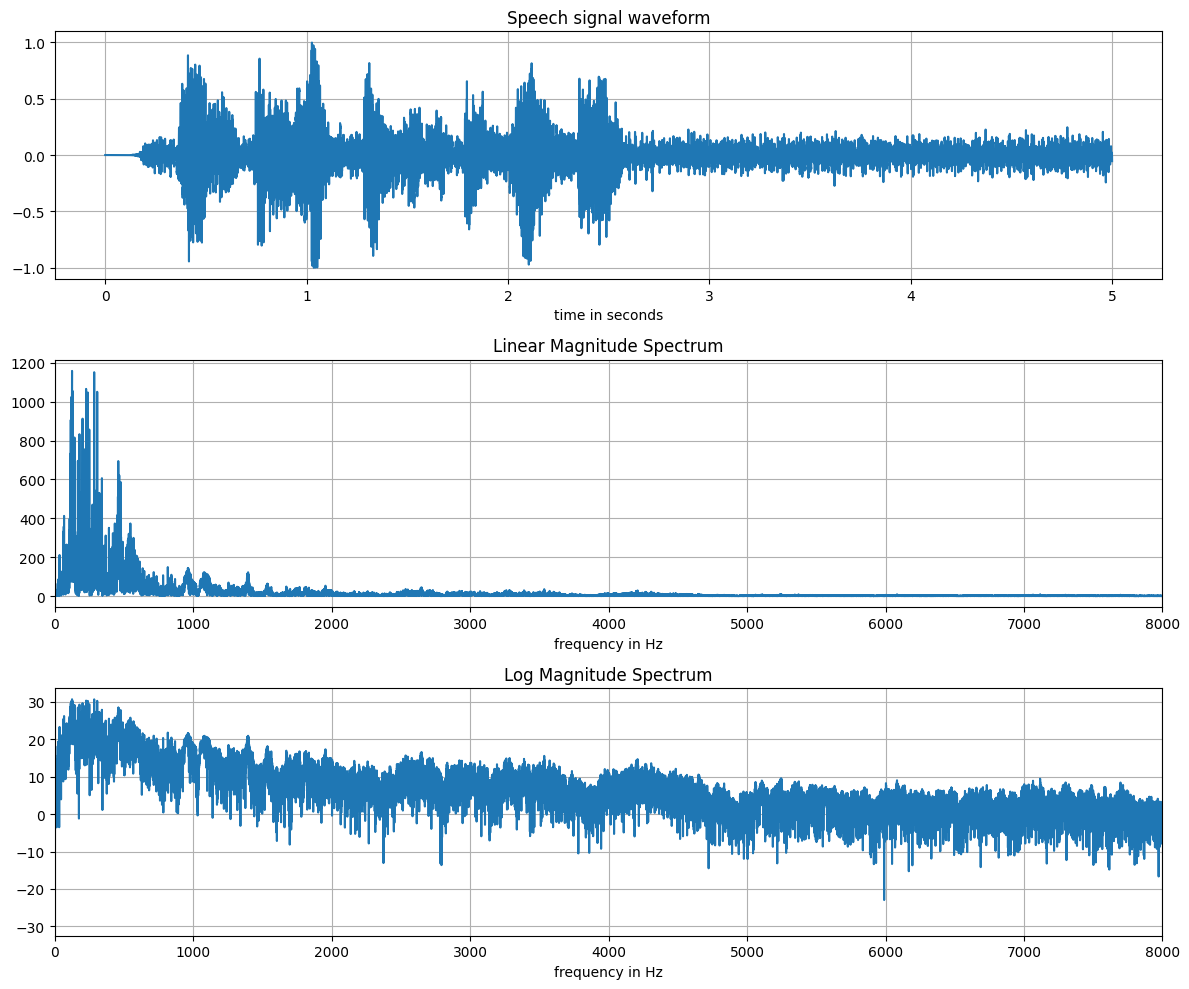

In [2]:
y = y / np.max(np.abs(y))

t = np.linspace(0, len(y)/sr, len(y))

n_fft = len(y)
D = np.fft.fft(y)
dfty = np.abs(D)

dfty = dfty[:len(dfty)//2]
freqs = np.fft.fftfreq(n_fft, 1/sr)[:n_fft//2]

dfty_log = 10 * np.log10(dfty + 1e-10)

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(t, y)
plt.title('Speech signal waveform')
plt.xlabel('time in seconds')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(freqs, dfty)
plt.title('Linear Magnitude Spectrum')
plt.xlabel('frequency in Hz')
plt.xlim(0, 8000) 
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(freqs, dfty_log)
plt.title('Log Magnitude Spectrum')
plt.xlabel('frequency in Hz')
plt.xlim(0, 8000)
plt.grid(True)

plt.tight_layout()
plt.show()

Hình 2 cho thấy phổ biên độ logarit của một đoạn tiếng nói có tiếng (voiced), tiếng nói không tiếng (unvoiced) và vùng im lặng (silence).
Ta thấy rằng rằng phổ biên độ logarit cho các vùng có tiếng, không tiếng và im lặng là khác nhau

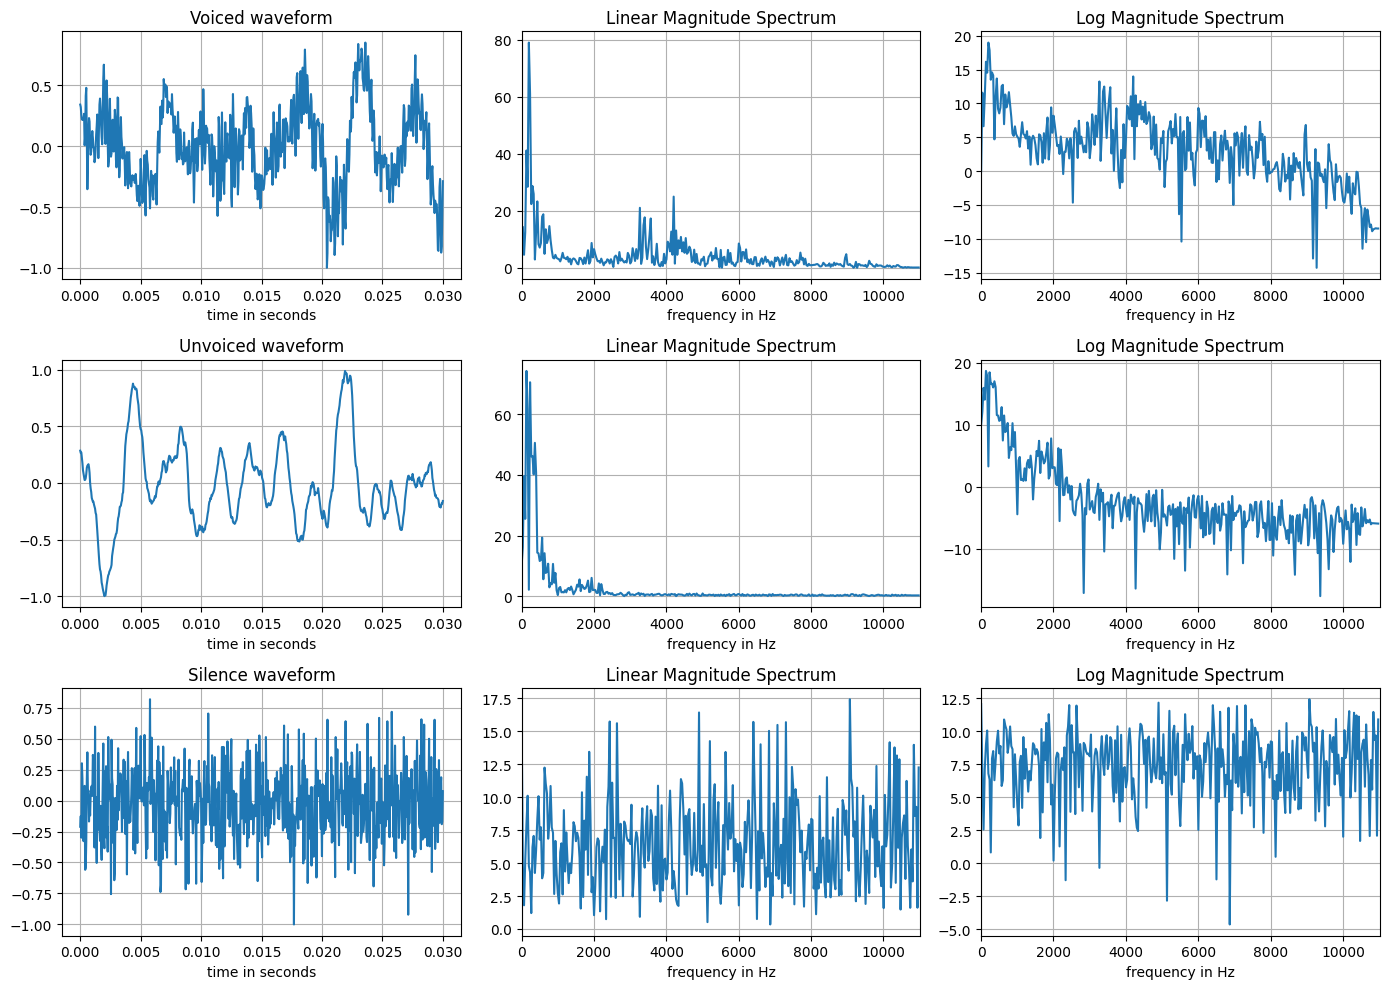

In [3]:
duration_sec = 0.030 
n_samples = int(duration_sec * sr)

y_voiced = y[int(1.2*sr) : int(1.2*sr)+n_samples]
y_unvoiced = y[int(2.8*sr) : int(2.8*sr)+n_samples] 
y_silence = np.zeros(n_samples) + 0.001 * np.random.randn(n_samples) 

segments = [('Voiced', y_voiced), ('Unvoiced', y_unvoiced), ('Silence', y_silence)]


plt.figure(figsize=(14, 10))

for i, (name, sig) in enumerate(segments):
    if np.max(np.abs(sig)) > 0:
        sig = sig / np.max(np.abs(sig))
    
    t_seg = np.linspace(0, duration_sec, len(sig))
    
    D_seg = np.abs(np.fft.fft(sig))
    D_seg = D_seg[:len(D_seg)//2]
    freqs_seg = np.fft.fftfreq(len(sig), 1/sr)[:len(sig)//2]
    
    D_seg_log = 10 * np.log10(D_seg + 1e-10)
    
    plt.subplot(3, 3, i*3 + 1)
    plt.plot(t_seg, sig)
    plt.title(f'{name} waveform')
    plt.xlabel('time in seconds')
    plt.grid()
    
    # 2. Linear Spectrum (Cột 2)
    plt.subplot(3, 3, i*3 + 2)
    plt.plot(freqs_seg, D_seg)
    plt.title('Linear Magnitude Spectrum')
    plt.xlabel('frequency in Hz')
    plt.xlim(0, sr/2)
    plt.grid()

    plt.subplot(3, 3, i*3 + 3)
    plt.plot(freqs_seg, D_seg_log)
    plt.title('Log Magnitude Spectrum')
    plt.xlabel('frequency in Hz')
    plt.xlim(0, sr/2)
    plt.grid()

plt.tight_layout()
plt.show()

Để phân tích phổ ngắn hạn, tín hiệu tiếng nói được chia thành các khối (block) có kích thước 10-30 ms với độ dịch chuyển (shift) 5-10 ms.
Phổ biên độ logarit được tính cho mỗi khối.
Hình 3 cho thấy biểu đồ 3D hiển thị phổ biên độ logarit của mỗi khung (frame) có kích thước 20 ms với độ dịch chuyển 10 ms.

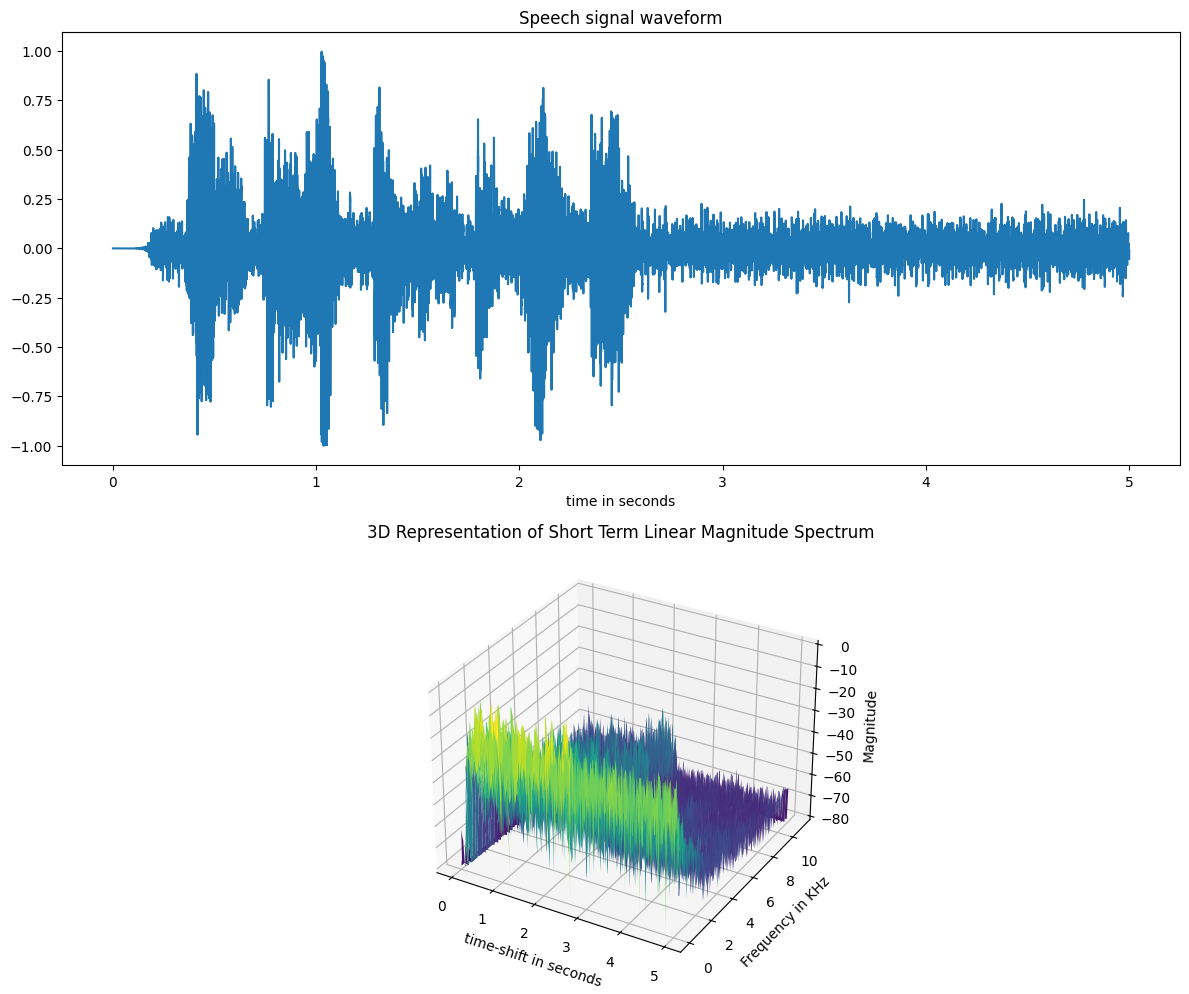

In [4]:
from mpl_toolkits.mplot3d import Axes3D

frame_length_ms = 20
frame_shift_ms = 10
n_fft = int(sr * frame_length_ms / 1000)
hop_length = int(sr * frame_shift_ms / 1000)

D_stft = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann'))
D_stft_log = librosa.amplitude_to_db(D_stft, ref=np.max)

times = librosa.times_like(D_stft, sr=sr, hop_length=hop_length)
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)/1000.0

T, F = np.meshgrid(times, freqs)

fig = plt.figure(figsize=(12, 10))

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(t, y)
ax1.set_title('Speech signal waveform')
ax1.set_xlabel('time in seconds')

ax2 = fig.add_subplot(2, 1, 2, projection='3d')

surf = ax2.plot_surface(T, F, D_stft_log, cmap='viridis', edgecolor='none')
ax2.set_title('3D Representation of Short Term Linear Magnitude Spectrum')
ax2.set_ylabel('Frequency in KHz')
ax2.set_xlabel('time-shift in seconds')
ax2.set_zlabel('Magnitude')
ax2.view_init(elev=30, azim=-60) 

plt.tight_layout()
plt.show()

Khái niệm về phổ thực và phổ chập (Concept of true and convolved spectra)
Phổ thực (True spectrum) của sóng sin 200 Hz được tính bằng cách lấy DTFT của toàn bộ tín hiệu hình sin.
Phổ chập (Convolved spectrum) được biểu diễn bằng cách lấy STFT của đoạn ngắn hạn 20-30 ms của sóng sin.
Phổ thực được biểu diễn bằng hàm xung (impulse function) tại 200 Hz, và phổ chập được biểu diễn bằng hàm sinc tập trung xung quanh 200 Hz

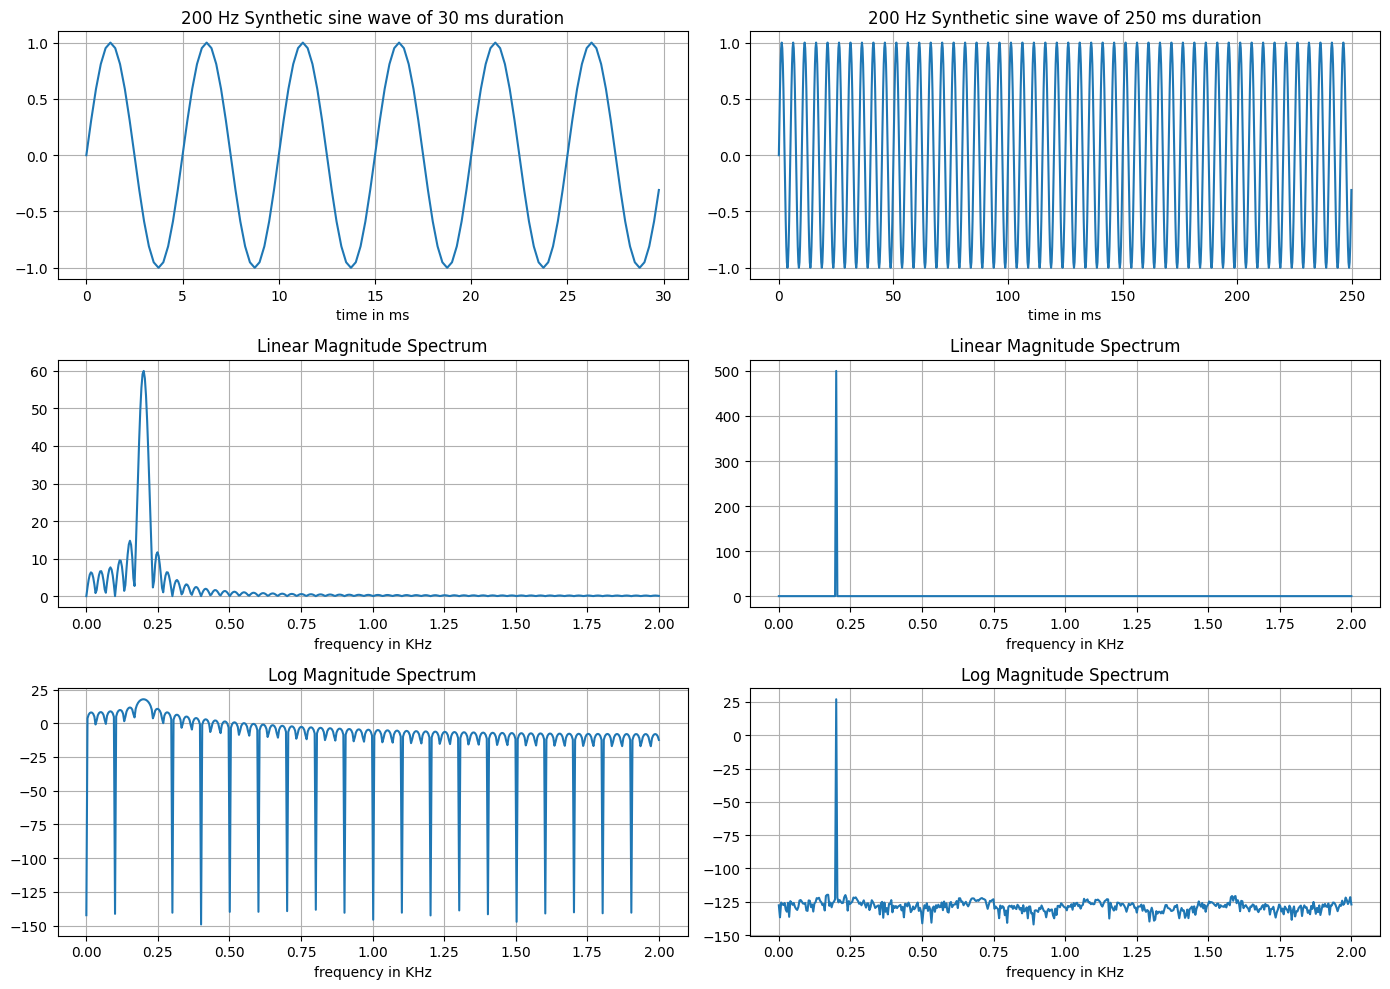

In [5]:
Fs_syn = 4000
f_syn = 200

t1 = np.arange(0, 0.03, 1/Fs_syn)
y1 = np.sin(2 * np.pi * f_syn * t1)
y1_pad = np.pad(y1, (0, 1000 - len(y1)), 'constant') 

t2 = np.arange(0, 0.25, 1/Fs_syn)
y2 = np.sin(2 * np.pi * f_syn * t2)
y2_pad = np.pad(y2, (0, 1000 - len(y2)), 'constant')

def plot_syn(ax_wave, ax_lin, ax_log, time, signal, title_wave):
    ax_wave.plot(time * 1000, signal) # time in ms
    ax_wave.set_title(title_wave)
    ax_wave.set_xlabel('time in ms')
    ax_wave.grid()

    
    dft = np.abs(np.fft.fft(y2_pad if len(signal) > 200 else y1_pad)) 
    dft = dft[:len(dft)//2]
    dft_log = 10 * np.log10(dft)
    
    freqs = np.linspace(0, Fs_syn/2000, len(dft))

    ax_lin.plot(freqs, dft)
    ax_lin.set_title('Linear Magnitude Spectrum')
    ax_lin.set_xlabel('frequency in KHz')
    ax_lin.grid()

    ax_log.plot(freqs, dft_log)
    ax_log.set_title('Log Magnitude Spectrum')
    ax_log.set_xlabel('frequency in KHz')
    ax_log.grid()

fig, axs = plt.subplots(3, 2, figsize=(14, 10))

plot_syn(axs[0,0], axs[1,0], axs[2,0], t1, y1, '200 Hz Synthetic sine wave of 30 ms duration')
plot_syn(axs[0,1], axs[1,1], axs[2,1], t2, y2, '200 Hz Synthetic sine wave of 250 ms duration')

plt.tight_layout()
plt.show()

Ảnh hưởng của hàm cửa sổ đối với phân tích phổ ngắn hạn (Effect of windowing function on short term spectral analysis)
Hình 5 cho thấy các hàm cửa sổ khác nhau như hình chữ nhật (rectangular), Hamming và Hanning trong miền thời gian và tần số

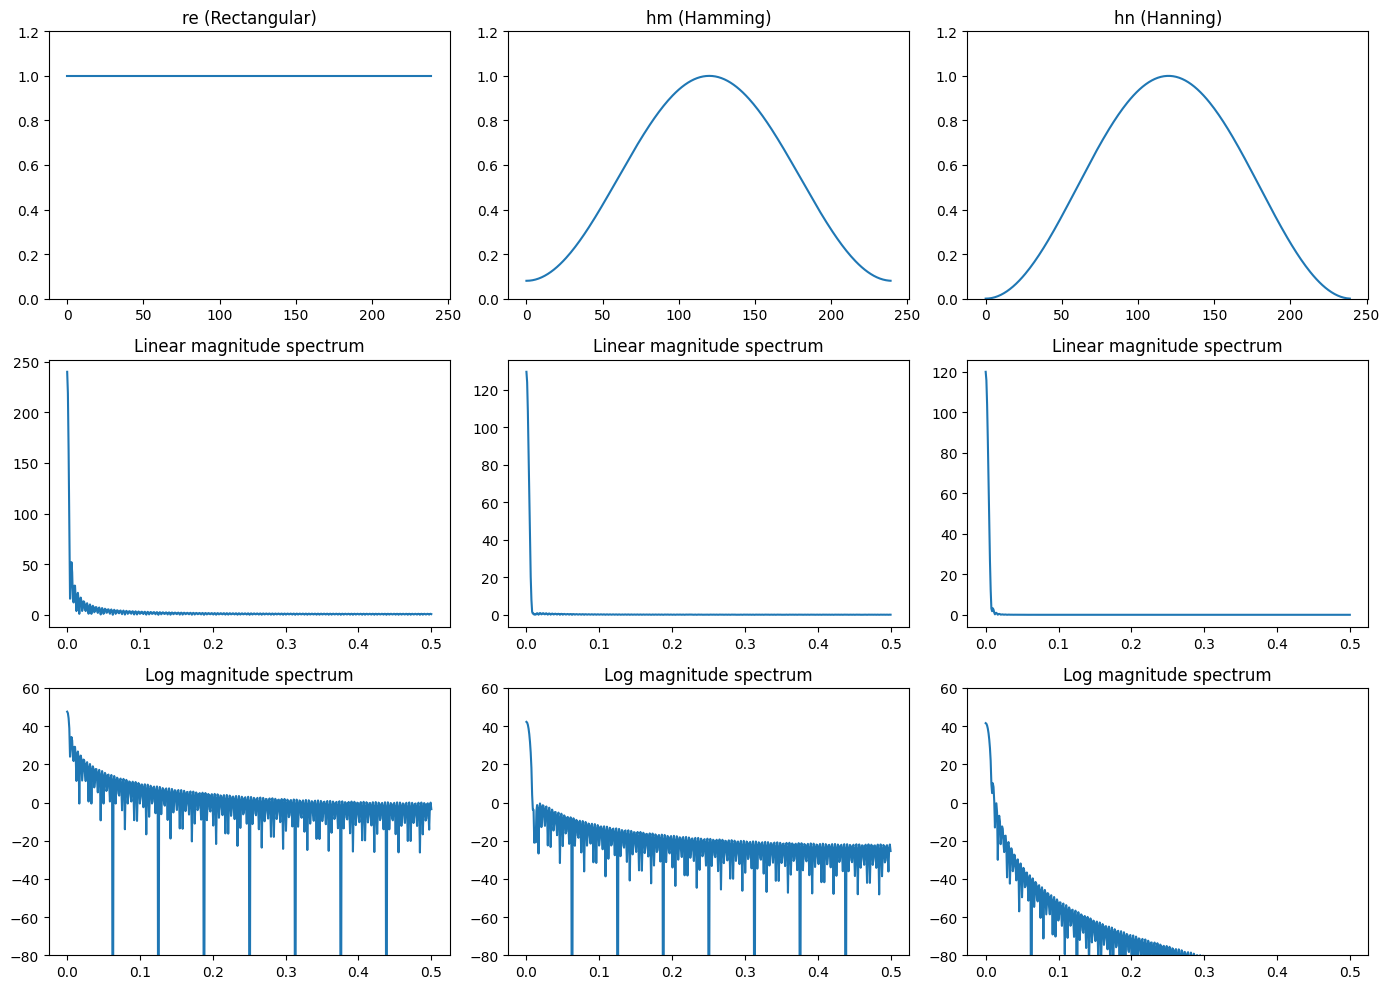

In [6]:
from scipy.signal import get_window

N_win = 240
Fs_win = 8000
win_types = ['boxcar', 'hamming', 'hann']
titles = ['re (Rectangular)', 'hm (Hamming)', 'hn (Hanning)']

fig, axs = plt.subplots(3, 3, figsize=(14, 10))

for i, w_type in enumerate(win_types):
    w = get_window(w_type, N_win)
    
    w_pad = np.pad(w, (0, 1024 - len(w)), 'constant')
    D_w = np.abs(np.fft.fft(w_pad))
    D_w = D_w[:len(D_w)//2]
    D_w_log = 20 * np.log10(D_w + 1e-10) 
    
    f_axis = np.linspace(0, 0.5, len(D_w))
    
    axs[0, i].plot(w)
    axs[0, i].set_title(titles[i])
    axs[0, i].set_ylim(0, 1.2)
    
    axs[1, i].plot(f_axis, D_w)
    axs[1, i].set_title('Linear magnitude spectrum')
    
    axs[2, i].plot(f_axis, D_w_log)
    axs[2, i].set_title('Log magnitude spectrum')
    axs[2, i].set_ylim(-80, 60)

plt.tight_layout()
plt.show()

Phân tích phổ tiếng nói bằng các hàm cửa sổ
Hình 6 cho thấy phổ biên độ ngắn hạn của một đoạn tiếng nói có tiếng 30 ms bằng cách sử dụng các hàm cửa sổ hình chữ nhật, Hamming và Hanning.

Phổ STFT sử dụng cửa sổ hình chữ nhật được nhận thấy là nhiễu hơn so với phổ STFT do các hàm cửa sổ khác. Điều này là do sự rò rỉ phổ cao hơn trong cửa sổ hình chữ nhật so với các hàm cửa sổ khác

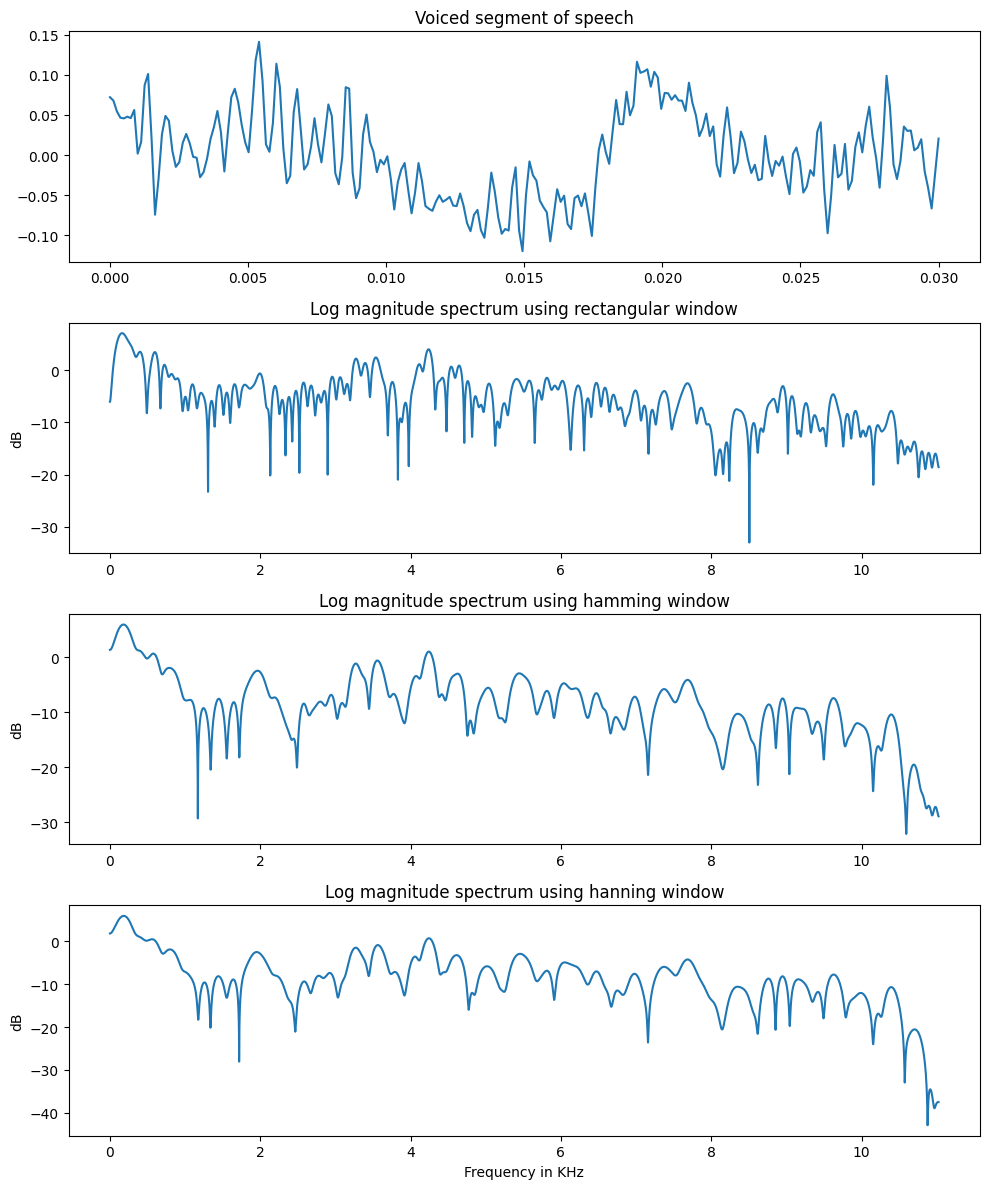

In [7]:
y_v = y_voiced[:240]
if len(y_v) < 240: y_v = np.pad(y_v, (0, 240-len(y_v)))

def plot_windowed_speech(ax, signal, window_name, plot_title):
    if window_name == 'rect':
        win = np.ones(len(signal))
    elif window_name == 'hamming':
        win = np.hamming(len(signal))
    elif window_name == 'hann':
        win = np.hanning(len(signal))
    
    y_win = signal * win
    
    y_pad = np.pad(y_win, (0, 10000), 'constant')
    D = np.abs(np.fft.fft(y_pad))
    D = D[:len(D)//2]
    D_log = 10 * np.log10(D + 1e-10)
    
    f_axis = np.linspace(0, sr/2000, len(D)) # KHz
    
    ax.plot(f_axis, D_log)
    ax.set_title(plot_title)
    ax.set_ylabel('dB')

fig, axs = plt.subplots(4, 1, figsize=(10, 12))

axs[0].plot(np.linspace(0, 0.03, len(y_v)), y_v)
axs[0].set_title('Voiced segment of speech')

plot_windowed_speech(axs[1], y_v, 'rect', 'Log magnitude spectrum using rectangular window')

plot_windowed_speech(axs[2], y_v, 'hamming', 'Log magnitude spectrum using hamming window')

plot_windowed_speech(axs[3], y_v, 'hann', 'Log magnitude spectrum using hanning window')
axs[3].set_xlabel('Frequency in KHz')

plt.tight_layout()
plt.show()


Tương tự, hình 7 thể hiện phổ biên độ ngắn hạn của một đoạn tiếng không có tiếng nói dài 30 ms bằng cách sử dụng các hàm cửa sổ hình chữ nhật, Hamming và Hanning

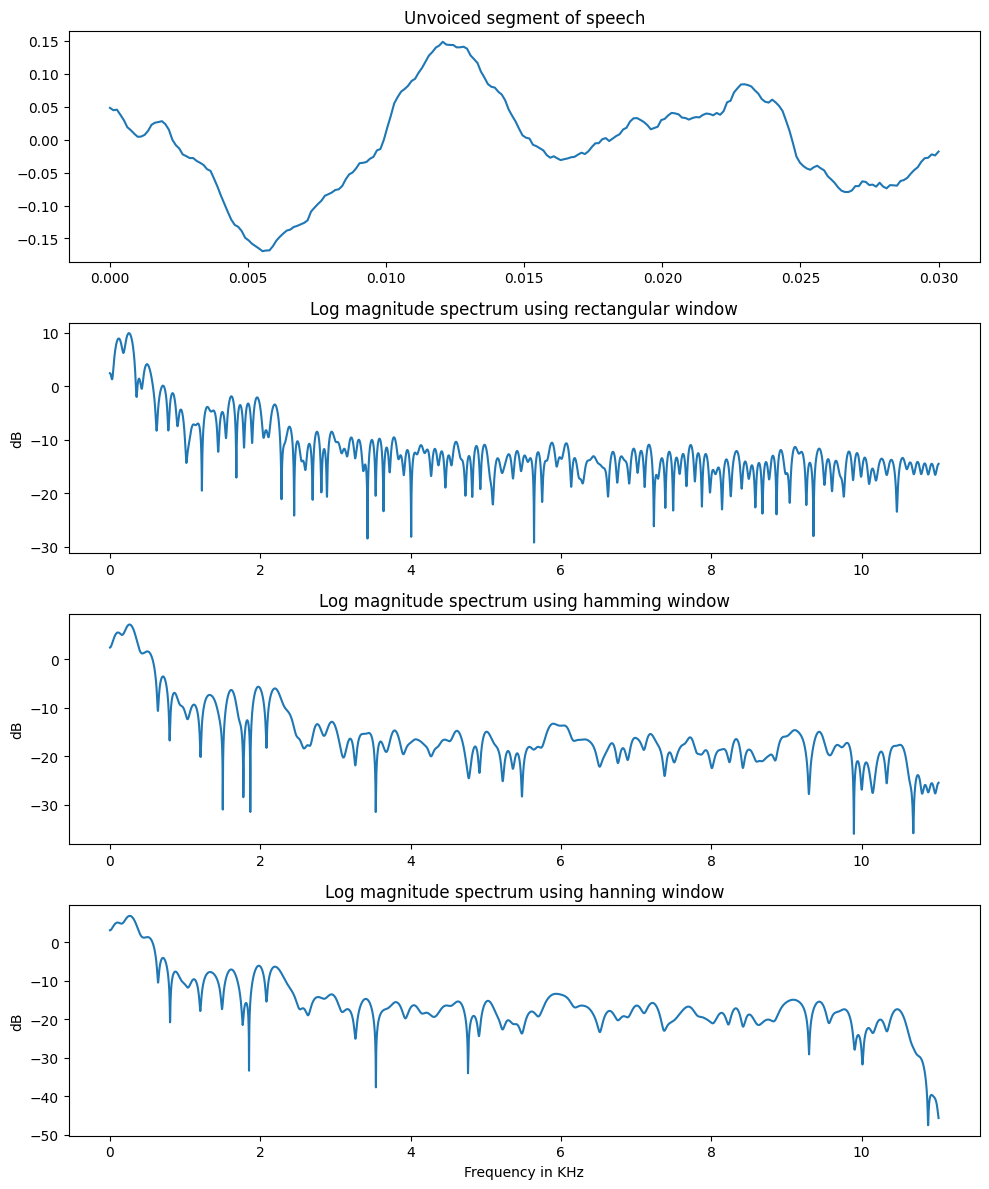

In [8]:
y_v = y_unvoiced[:240]
if len(y_v) < 240: y_v = np.pad(y_v, (0, 240-len(y_v)))

def plot_windowed_speech(ax, signal, window_name, plot_title):
    if window_name == 'rect':
        win = np.ones(len(signal))
    elif window_name == 'hamming':
        win = np.hamming(len(signal))
    elif window_name == 'hann':
        win = np.hanning(len(signal))
    
    y_win = signal * win
    
    y_pad = np.pad(y_win, (0, 10000), 'constant')
    D = np.abs(np.fft.fft(y_pad))
    D = D[:len(D)//2]
    D_log = 10 * np.log10(D + 1e-10)
    
    f_axis = np.linspace(0, sr/2000, len(D)) # KHz
    
    ax.plot(f_axis, D_log)
    ax.set_title(plot_title)
    ax.set_ylabel('dB')

fig, axs = plt.subplots(4, 1, figsize=(10, 12))

axs[0].plot(np.linspace(0, 0.03, len(y_v)), y_v)
axs[0].set_title('Unvoiced segment of speech')

plot_windowed_speech(axs[1], y_v, 'rect', 'Log magnitude spectrum using rectangular window')

plot_windowed_speech(axs[2], y_v, 'hamming', 'Log magnitude spectrum using hamming window')

plot_windowed_speech(axs[3], y_v, 'hann', 'Log magnitude spectrum using hanning window')
axs[3].set_xlabel('Frequency in KHz')

plt.tight_layout()
plt.show()


Hình 8 cho thấy phổ biên độ logarit ngắn hạn của đoạn tiếng nói có tiếng sử dụng kích thước khung là 3 ms, 30 ms và 300 ms.
Cửa sổ 3 ms: Quan sát thấy độ phân giải phổ kém (poor spectral resolution) do kích thước cửa sổ nhỏ.
Cửa sổ 300 ms: Quan sát thấy độ phân giải thời gian kém (poor time resolution).
Cửa sổ 30 ms: Phổ biên độ logarit của đoạn tiếng nói được cửa sổ hóa 30 ms cho thấy bao phổ âm thanh (vocal tract spectral envelope) và thông tin kích thích dưới dạng cao độ (pitch) và các hài âm của nó (harmonics).

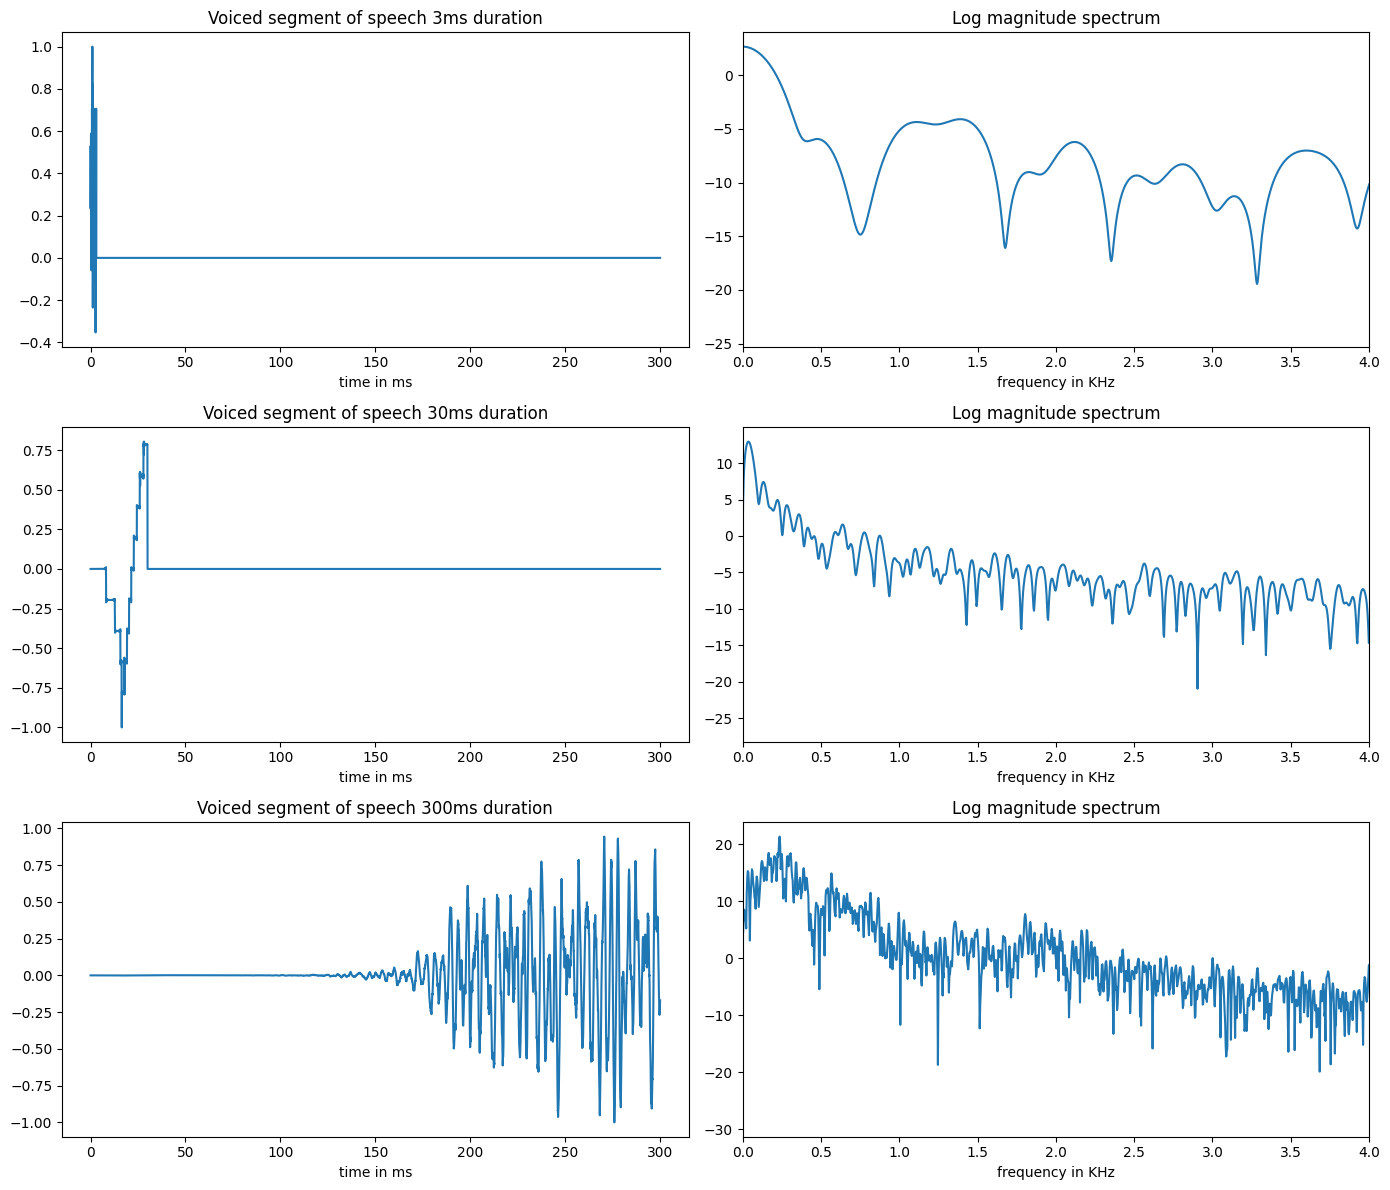

In [9]:
sizes_ms = [3, 30, 300]

fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for i, size in enumerate(sizes_ms):
    n_samp = int(size * sr)//1000
    
    segment = y[:n_samp]
    
    segment = segment / np.max(np.abs(segment))
    seg_pad = np.pad(segment, (0, int(0.3*sr) - len(segment)), 'constant')
    
    win = np.hamming(len(seg_pad))
    seg_win = seg_pad * win
    
    
    D = np.abs(np.fft.fft(seg_win))
    D = D[:len(D)//2]
    D_log = 10 * np.log10(D)
    freqs = np.linspace(0, sr/2000, len(D)) # KHz
    
    t_axis = np.linspace(0, 300, len(seg_pad))
    axs[i, 0].plot(t_axis, seg_pad)
    axs[i, 0].set_title(f'Voiced segment of speech {size}ms duration')
    axs[i, 0].set_xlabel('time in ms')
    
    axs[i, 1].plot(freqs, D_log)
    axs[i, 1].set_title('Log magnitude spectrum')
    axs[i, 1].set_xlabel('frequency in KHz')
    axs[i, 1].set_xlim(0, 4)

plt.tight_layout()
plt.show()